In [1]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=6):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [4]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import math

In [5]:
# ===== Architecture of Prospective MLP =====
class TorchMLP(nn.Module):
    def __init__(self, in_dim=57):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.out(x).squeeze(-1)
        return x


# ===== Trainer =====
class TorchMLPTrainer:
    def __init__(self, in_dim, lr_group=(3e-3, 1e-2, 1e-2), weight_decay=1e-4, device=None, seed=42):
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = device
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        # Initialize Model
        self.model = TorchMLP(in_dim=in_dim).to(self.device)

        # Layer_wise Learning rate
        self.optimizer = optim.Adam(
            [
                {"params": self.model.fc1.parameters(), "lr": lr_group[0]},
                {"params": self.model.fc2.parameters(), "lr": lr_group[1]},
                {"params": self.model.out.parameters(), "lr": lr_group[2]},
            ],
            weight_decay=weight_decay,
        )

        self.loss_fn = nn.MSELoss()

    def partial_fit(self, X_np, y_np, epochs=50, batch_size=32):
        X = torch.from_numpy(X_np).float().to(self.device)
        y = torch.from_numpy(y_np).float().to(self.device)
        ds = TensorDataset(X, y)
        dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

        self.model.train()
        for _ in range(epochs):
            for xb, yb in dl:
                pred = self.model(xb)
                loss = self.loss_fn(pred, yb)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

    @torch.no_grad()
    def predict(self, X_np):
        self.model.eval()
        X = torch.from_numpy(X_np).float().to(self.device)
        return self.model(X).detach().cpu().numpy()

In [ ]:
gamma = 0.5
Ts = [0,128,256,512,750,1024,1250,1500,2048]

T0 = 128          # Min Time
base_epoch = 200  # Min Epoch

for rep in range(10):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(
            rewards_in_period = rewards_in_period,
            session_duration = 500000,
            tdim=50,
            n_sessions=1,
            seed  = 515 + rep
        )

        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

        trainer = TorchMLPTrainer(in_dim=new_state_oh.shape[1])

        for T in Ts:
            if T == 0:
                def random_predictor(X):
                    return np.random.choice(irewards, size= X.shape[0])
                predictor = random_predictor
            else: 
                X_train = new_state_oh[:T,:]
                Y_train = irewards[:T]

            # Dynamic number of epochs
                epochs = int(base_epoch * math.log2(T / T0 + 1))
                trainer.partial_fit(X_train, Y_train, epochs=epochs)
            print(f"{T} training done (epochs={epochs})")

            current_state = states[T,0]
            future_states = [current_state]

            for delta_t in range(100):
                df_all_paths = enumerate_paths(
                    x0=current_state,
                    t_inital = T+delta_t,
                    t_prime=t_prime
                )
                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(
                        np.ones(cand_pe.shape[0])*curr_time,
                        tdim=50
                    )
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = trainer.predict(features)

                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                rewards_matrix = df_ireward.iloc[:, 1:].values
                discounts = gamma ** np.arange(1, t_prime+1)

                discounted_returns = rewards_matrix * discounts
                total_discounted = discounted_returns.sum(axis=1)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                future_states.append(next_state)
                current_state = next_state

            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            print(np.sum(preward_opt_test))
            print(np.sum(preward))
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print("Pregret:", pregret)

            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PAFM/NN/NN_onehot_w_lookahead_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )

## Permuted T=0


0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


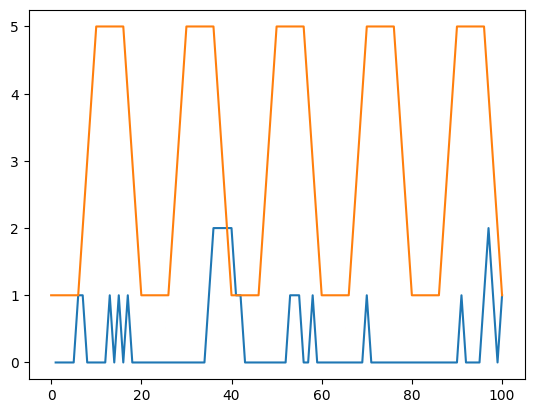

128 training done (epochs=200)
226.52947834139022
100.16923224017675
Pregret: 1.2636024610121346


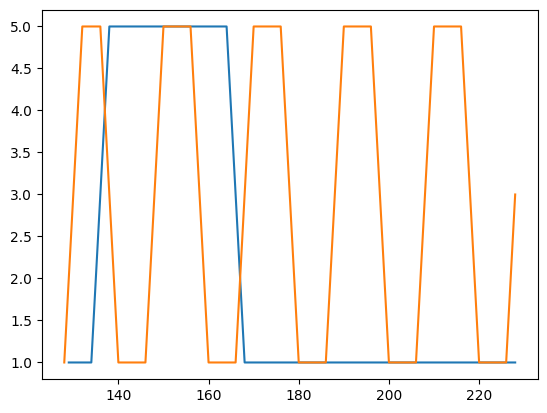

256 training done (epochs=316)
242.07326268668774
124.71139312982405
Pregret: 1.173618695568637


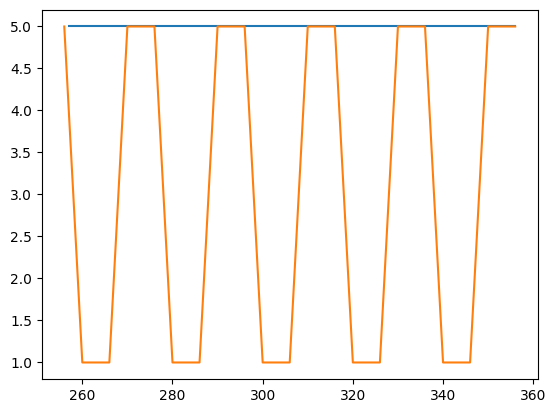

512 training done (epochs=464)
244.2386545823021
139.41672622520258
Pregret: 1.0482192835709951


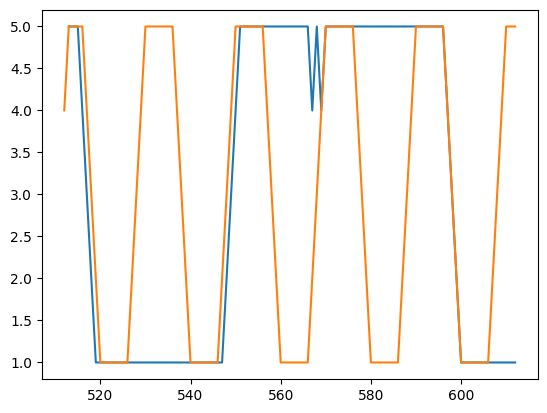

750 training done (epochs=555)
240.517988838869
178.11037838486513
Pregret: 0.6240761045400387


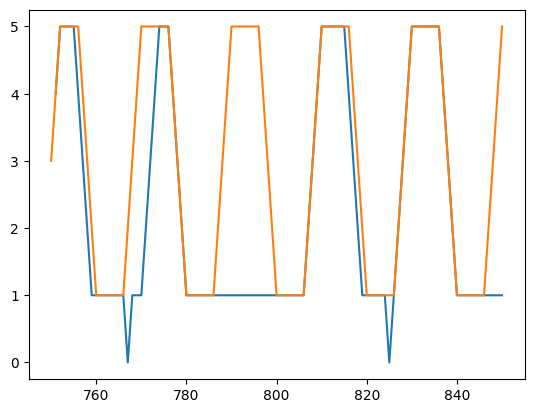

1024 training done (epochs=633)
243.60850098328575
180.5516371369425
Pregret: 0.6305686384634325


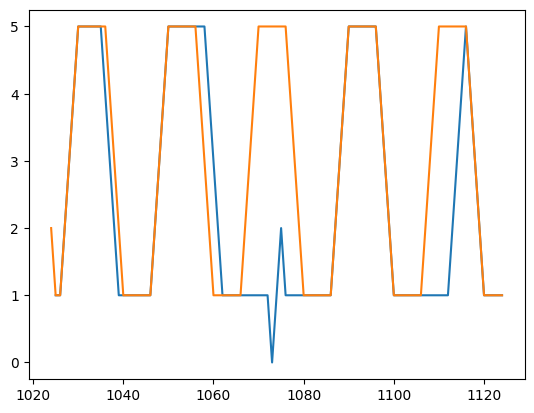

1250 training done (epochs=685)
240.517988838869
240.517988838869
Pregret: 0.0


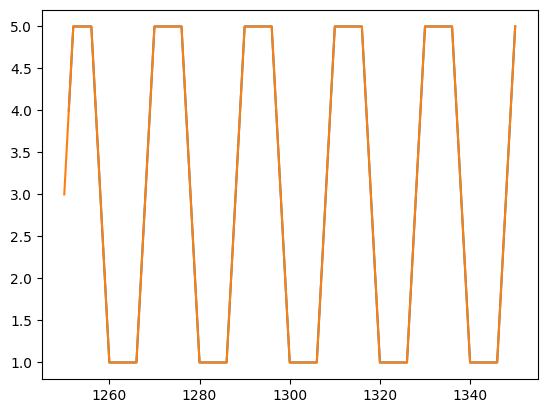

1500 training done (epochs=733)
237.09798883886901
237.09798883886901
Pregret: 0.0


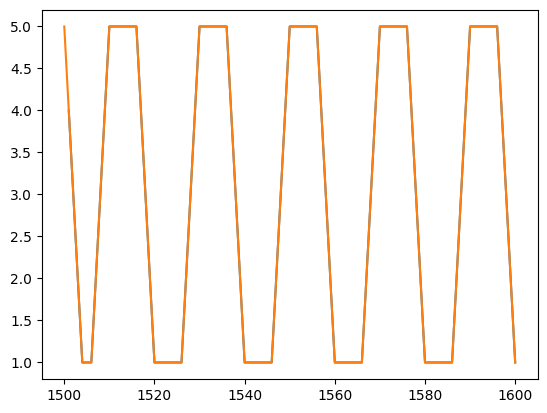

2048 training done (epochs=817)
236.02947834139022
236.02947834139022
Pregret: 0.0


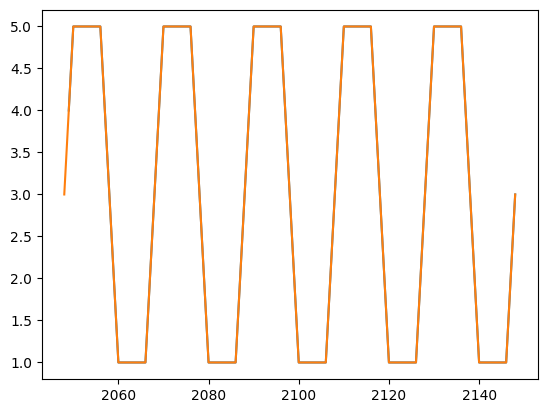

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


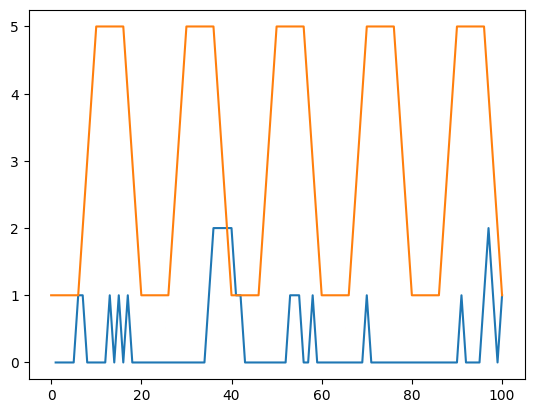

128 training done (epochs=200)
231.02947834139022
124.47404754520481
Pregret: 1.0655543079618541


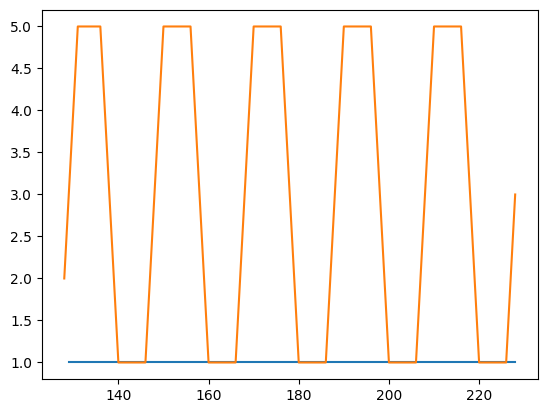

256 training done (epochs=316)
242.07326268668774
99.82321830530992
Pregret: 1.4225004438137783


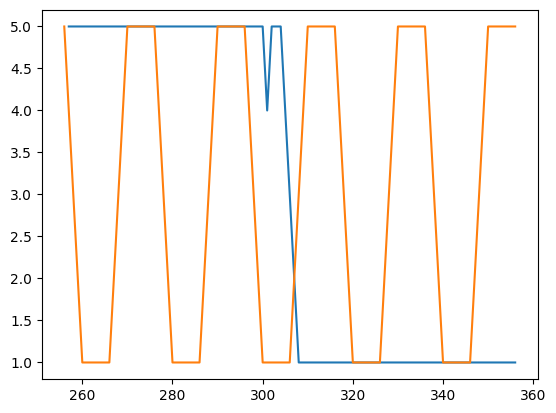

512 training done (epochs=464)
244.2386545823021
125.55796214064048
Pregret: 1.1868069244166162


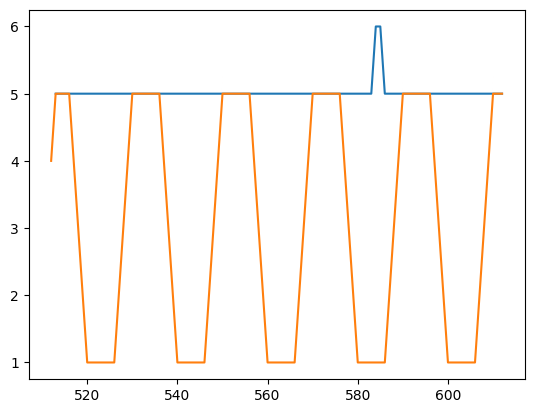

750 training done (epochs=555)
240.517988838869
169.28534832321122
Pregret: 0.7123264051565777


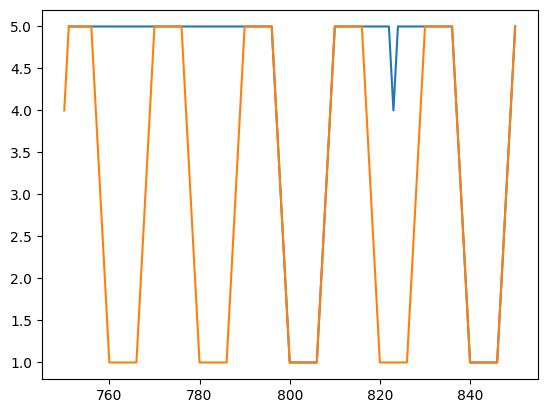

1024 training done (epochs=633)
243.37522098328574
243.37522098328574
Pregret: 0.0


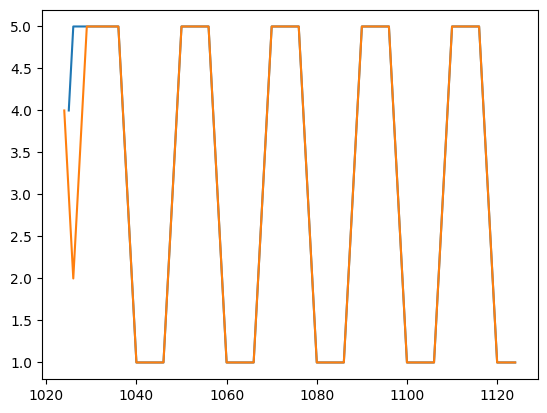

1250 training done (epochs=685)
240.517988838869
240.517988838869
Pregret: 0.0


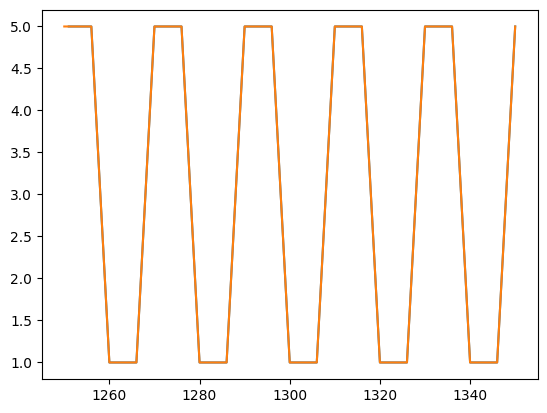

1500 training done (epochs=733)
240.517988838869
240.517988838869
Pregret: 0.0


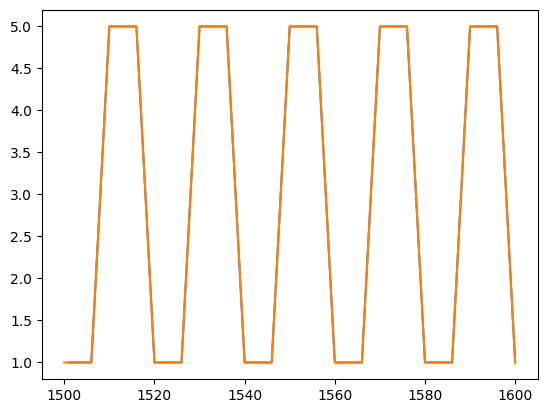

2048 training done (epochs=817)
236.02947834139022
236.02947834139022
Pregret: 0.0


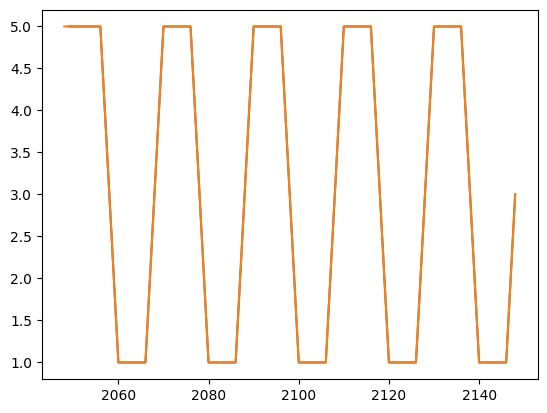

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


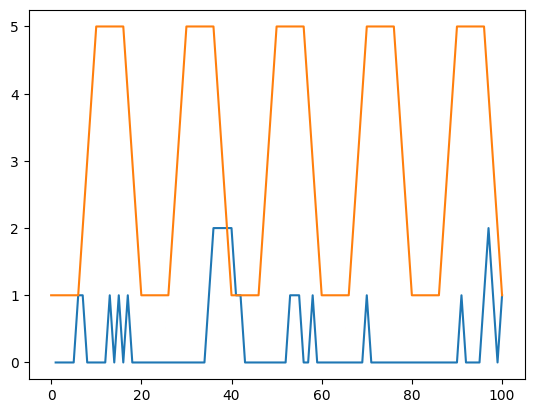

128 training done (epochs=200)
236.02947834139022
137.1240475452048
Pregret: 0.9890543079618541


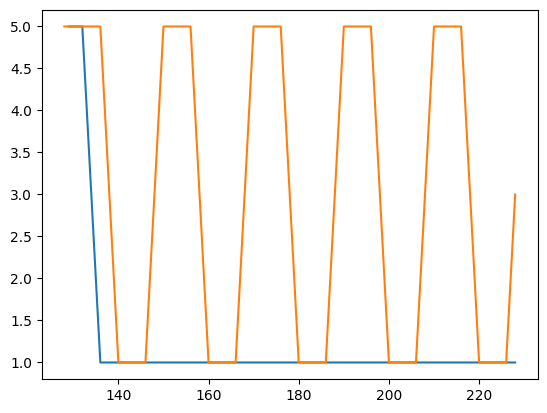

256 training done (epochs=316)
242.07326268668774
122.4597891940514
Pregret: 1.1961347349263634


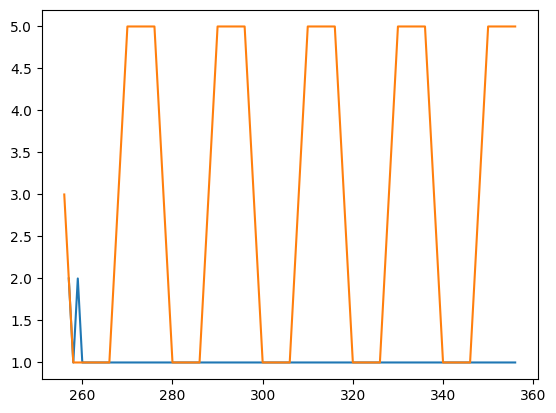

512 training done (epochs=464)
244.2386545823021
101.68143700678317
Pregret: 1.4255721757551894


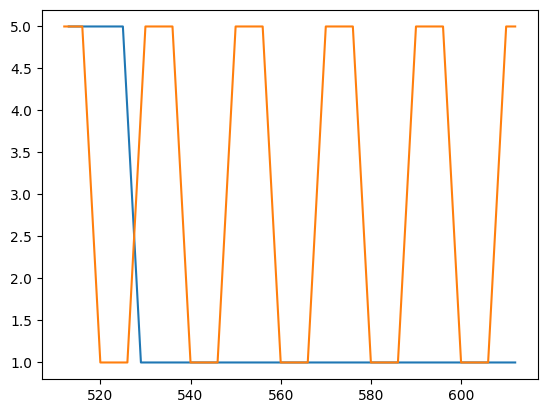

750 training done (epochs=555)
235.963988838869
184.08609998515416
Pregret: 0.5187788885371484


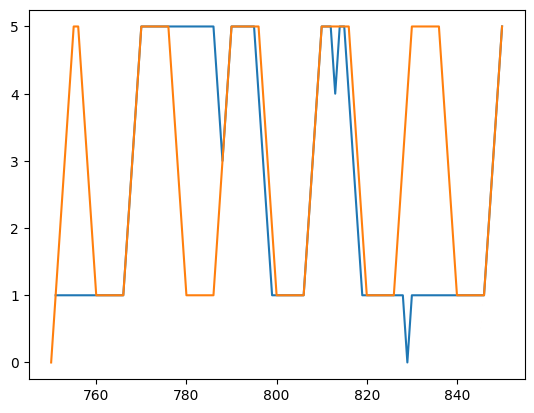

1024 training done (epochs=633)
243.60850098328575
181.1769178730871
Pregret: 0.6243158311019866


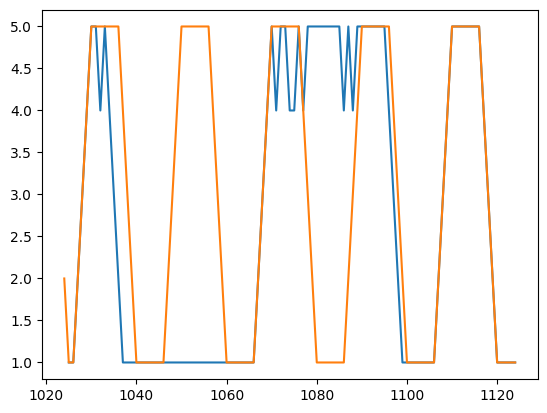

1250 training done (epochs=685)
240.517988838869
240.517988838869
Pregret: 0.0


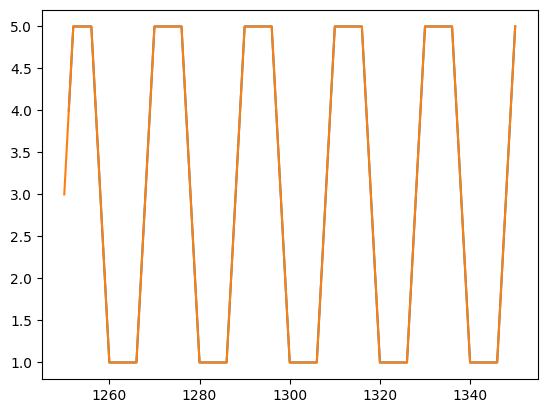

1500 training done (epochs=733)
240.517988838869
240.517988838869
Pregret: 0.0


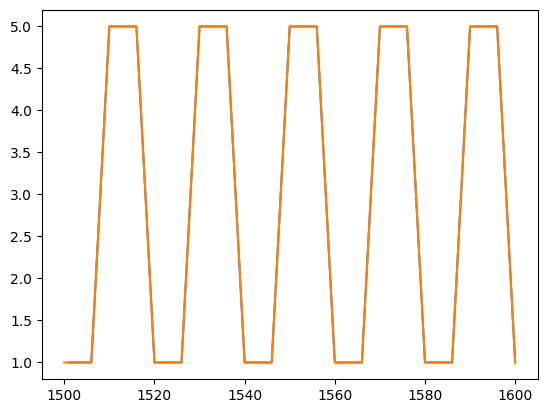

2048 training done (epochs=817)
223.37947834139024
223.37947834139024
Pregret: 0.0


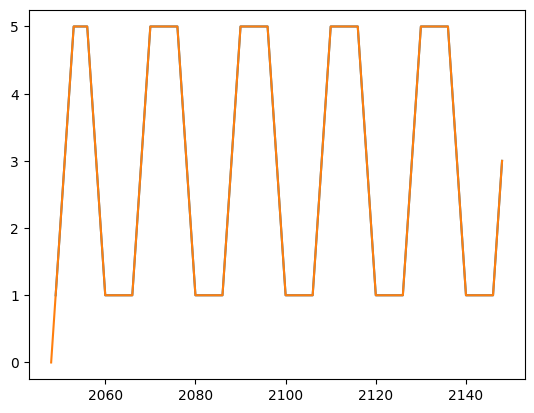

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


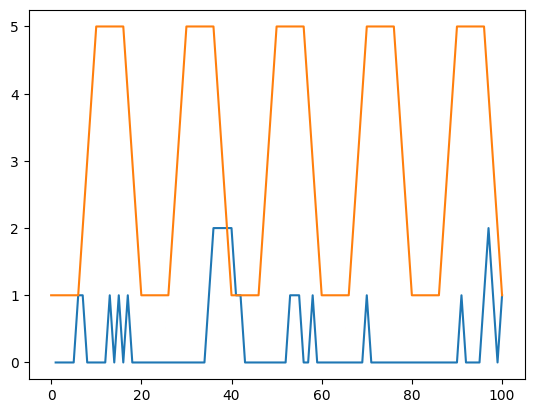

128 training done (epochs=200)
226.52947834139022
99.66283462726005
Pregret: 1.2686664371413017


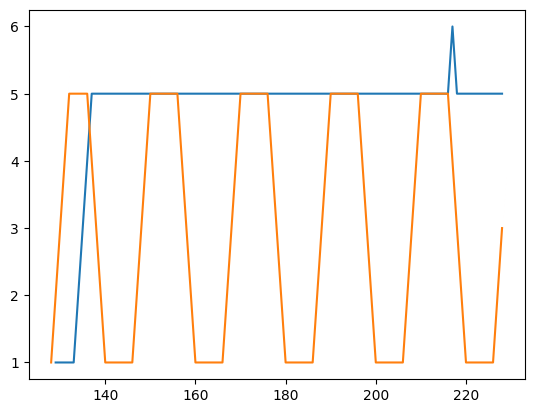

256 training done (epochs=316)
242.07326268668774
124.71139312982405
Pregret: 1.173618695568637


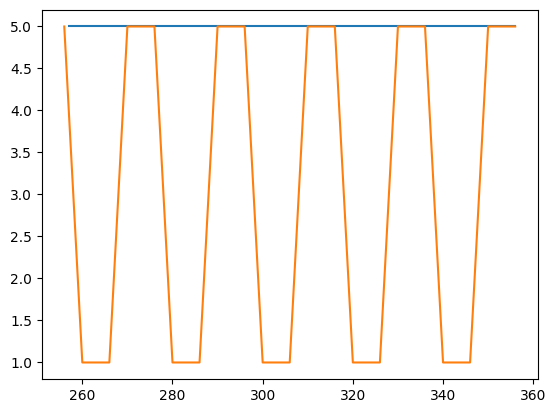

512 training done (epochs=464)
244.2386545823021
101.68657846014307
Pregret: 1.4255207612215903


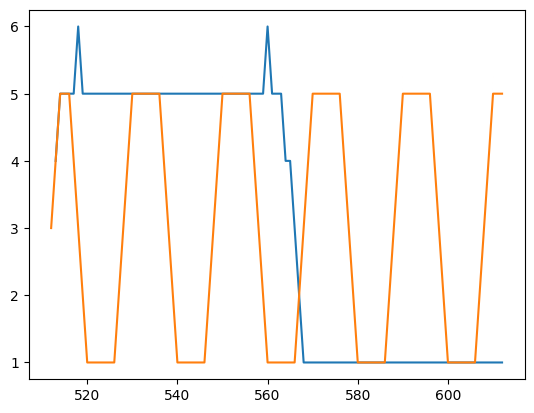

750 training done (epochs=555)
240.517988838869
134.69891408861793
Pregret: 1.0581907475025107


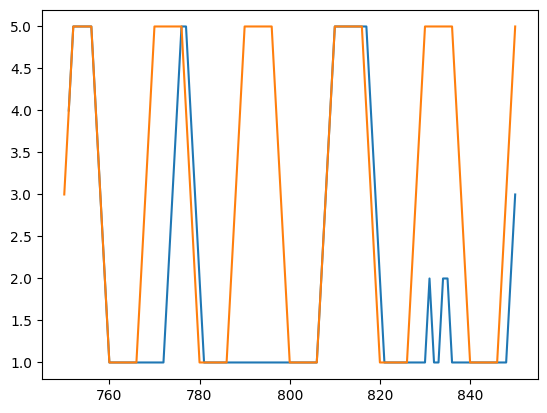

1024 training done (epochs=633)
243.37522098328574
243.37522098328574
Pregret: 0.0


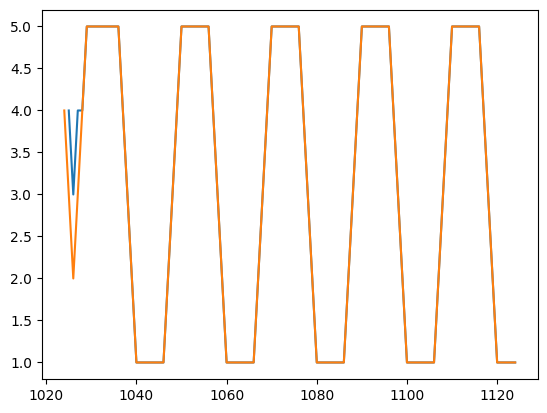

1250 training done (epochs=685)
238.71798883886902
238.71798883886902
Pregret: 0.0


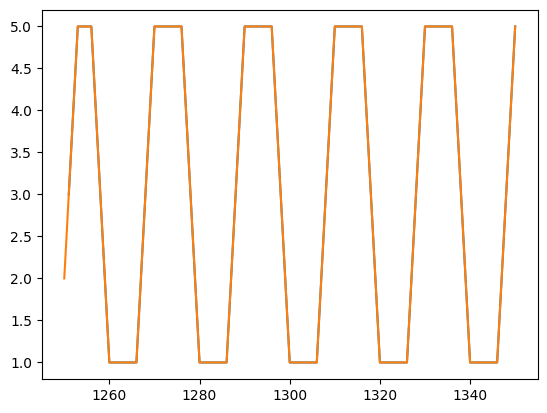

1500 training done (epochs=733)
238.71798883886902
238.71798883886902
Pregret: 0.0


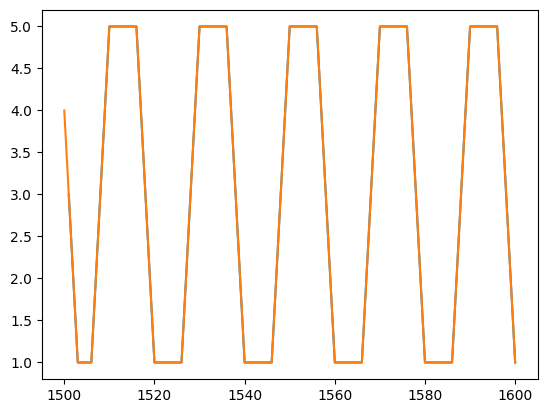

2048 training done (epochs=817)
236.02947834139022
236.02947834139022
Pregret: 0.0


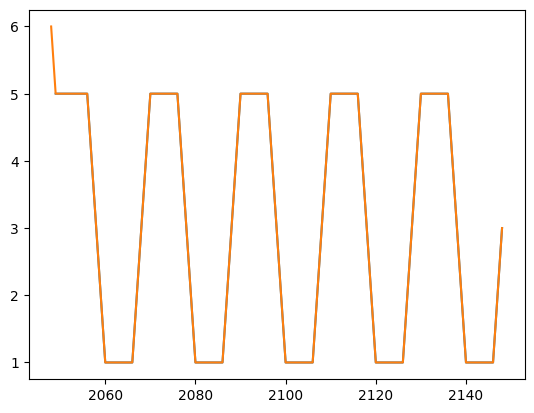

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


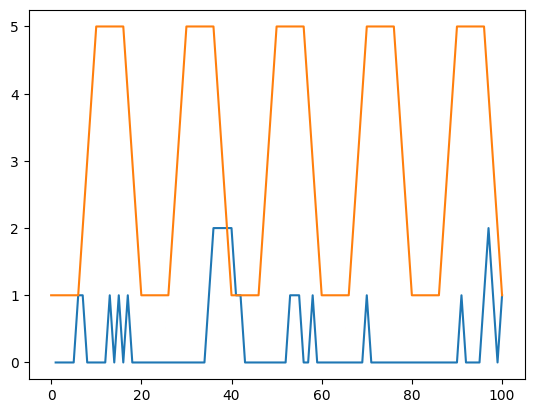

128 training done (epochs=200)
226.52947834139022
124.47404754520481
Pregret: 1.020554307961854


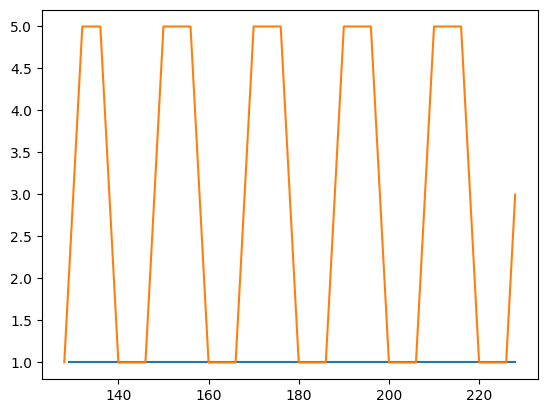

256 training done (epochs=316)
242.07326268668774
122.4597891940514
Pregret: 1.1961347349263634


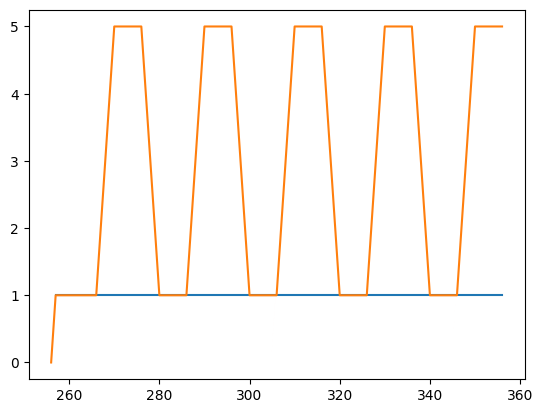

512 training done (epochs=464)
244.2386545823021
101.68132966024545
Pregret: 1.4255732492205664


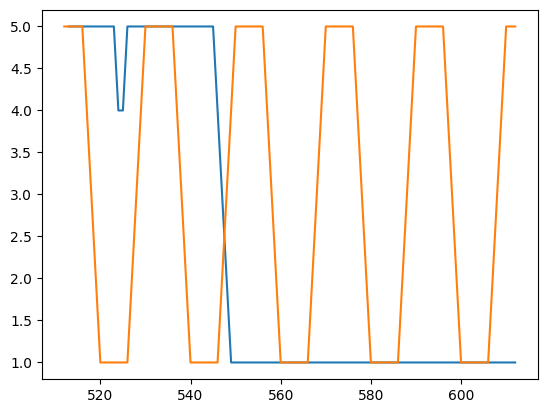

750 training done (epochs=555)
238.71798883886902
148.44298834300417
Pregret: 0.9027500049586484


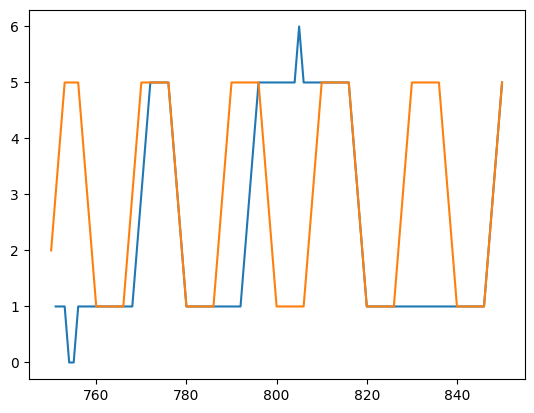

1024 training done (epochs=633)
243.60850098328575
242.6750002769082
Pregret: 0.009335007063775436


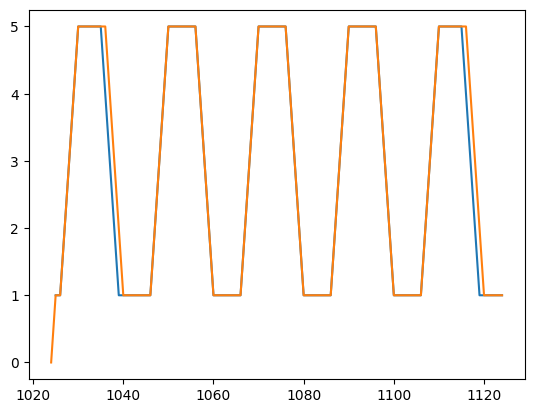

1250 training done (epochs=685)
240.517988838869
240.517988838869
Pregret: 0.0


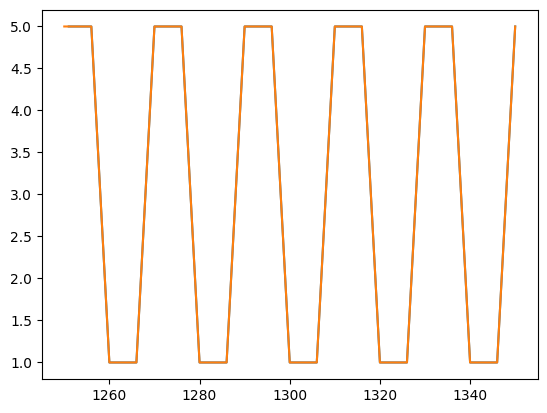

1500 training done (epochs=733)
238.71798883886902
238.251428838869
Pregret: 0.004665600000000154


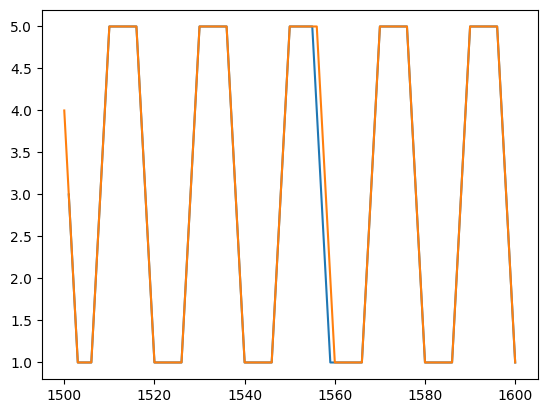

2048 training done (epochs=817)
226.52947834139022
226.52947834139022
Pregret: 0.0


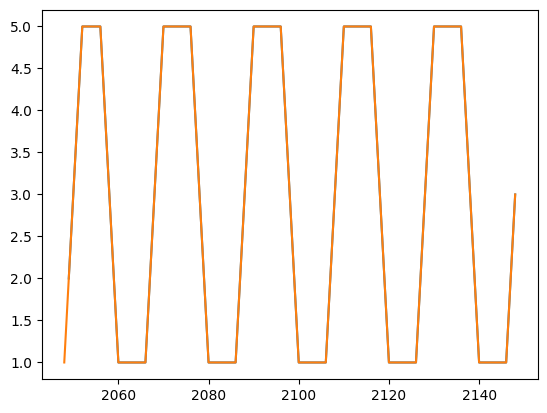

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


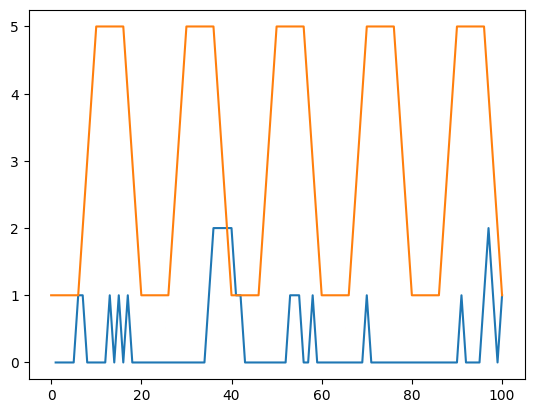

128 training done (epochs=200)
236.02947834139022
117.60693974017046
Pregret: 1.1842253860121976


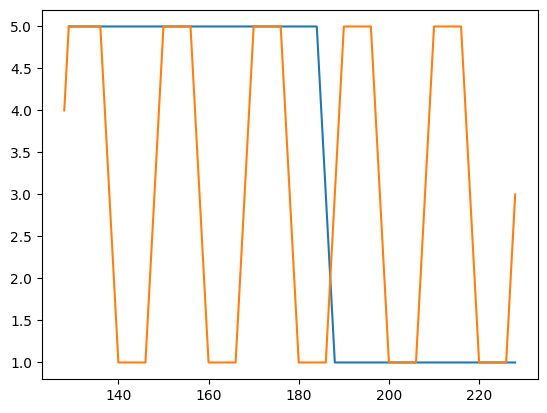

256 training done (epochs=316)
233.32326268668774
122.61048227127795
Pregret: 1.107127804154098


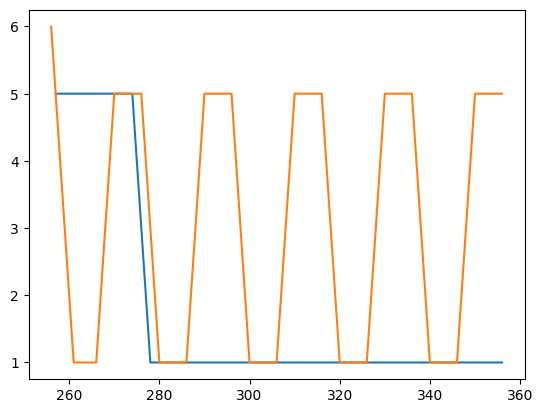

512 training done (epochs=464)
244.2386545823021
101.58055270024691
Pregret: 1.4265810188205519


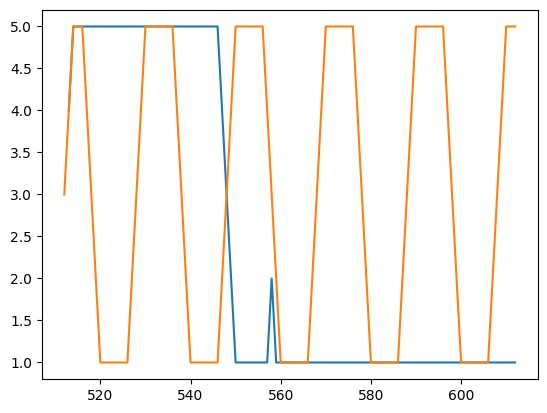

750 training done (epochs=555)
240.517988838869
122.37527078698608
Pregret: 1.1814271805188292


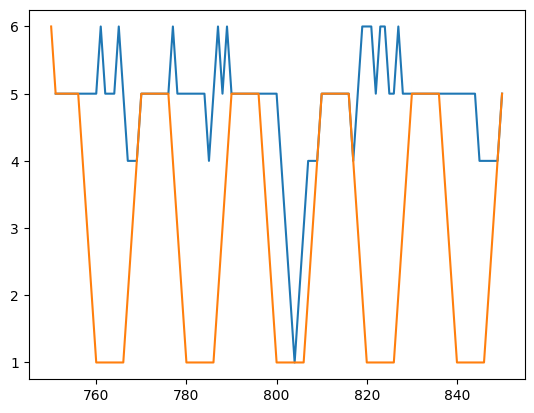

1024 training done (epochs=633)
243.60850098328575
212.5042957480081
Pregret: 0.3110420523527765


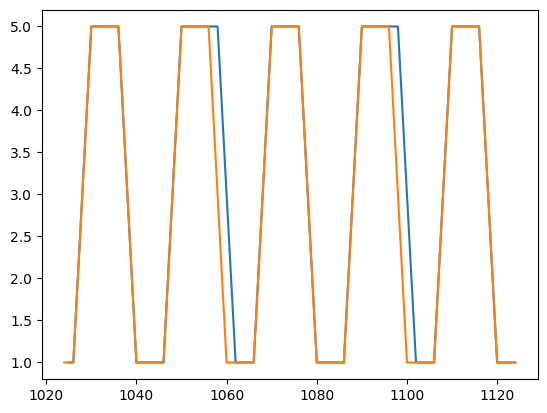

1250 training done (epochs=685)
235.963988838869
235.963988838869
Pregret: 0.0


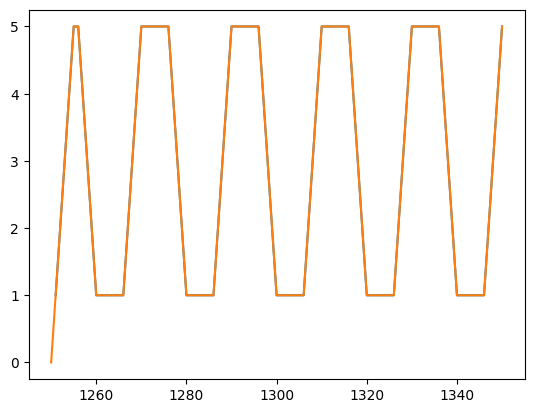

1500 training done (epochs=733)
240.517988838869
240.517988838869
Pregret: 0.0


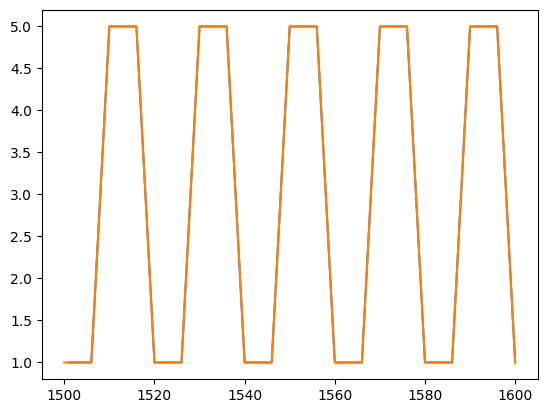

2048 training done (epochs=817)
236.02947834139022
236.02947834139022
Pregret: 0.0


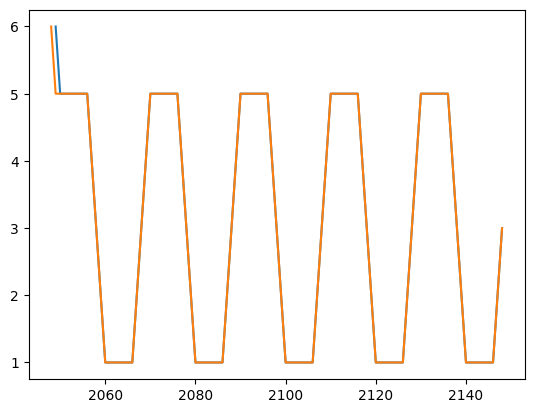

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


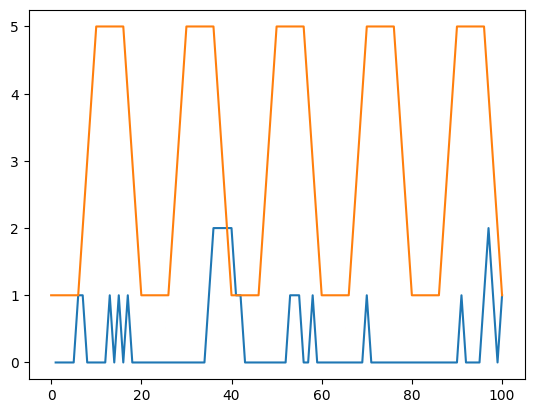

128 training done (epochs=200)
236.02947834139022
139.1490475452048
Pregret: 0.9688043079618541


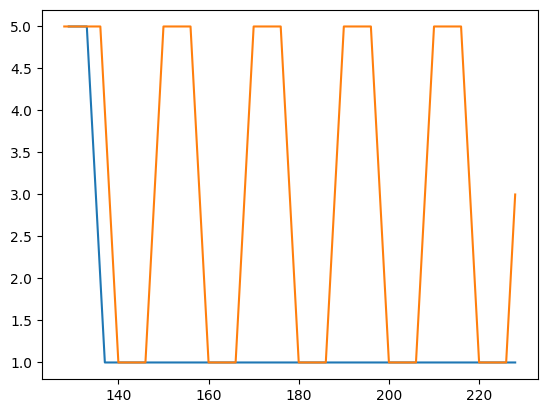

256 training done (epochs=316)
242.07326268668774
124.71139312982405
Pregret: 1.173618695568637


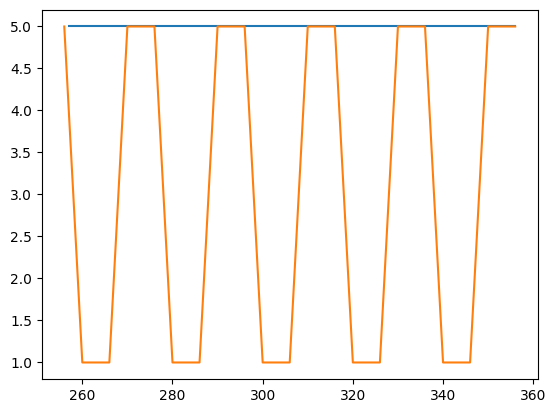

512 training done (epochs=464)
244.2386545823021
125.55796214064048
Pregret: 1.1868069244166162


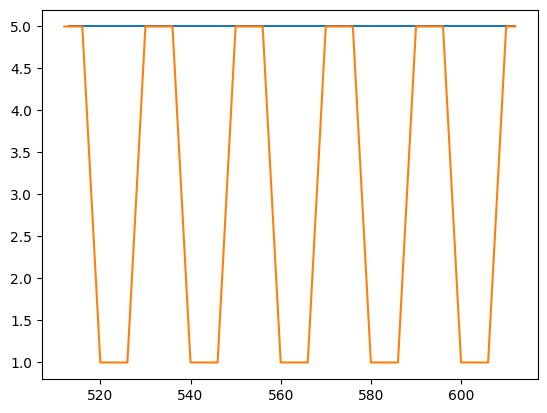

750 training done (epochs=555)
240.517988838869
109.32030752062047
Pregret: 1.3119768131824854


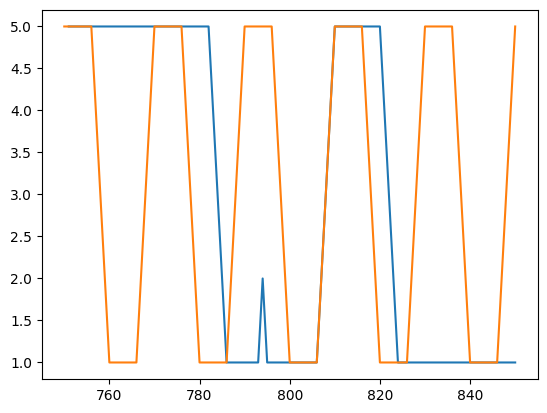

1024 training done (epochs=633)
243.60850098328575
189.0674733573676
Pregret: 0.5454102762591816


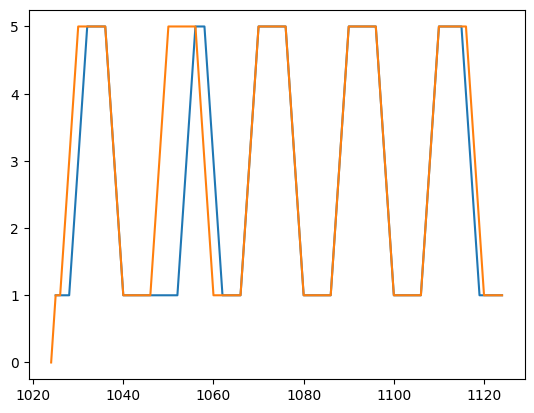

1250 training done (epochs=685)
237.09798883886901
237.09798883886901
Pregret: 0.0


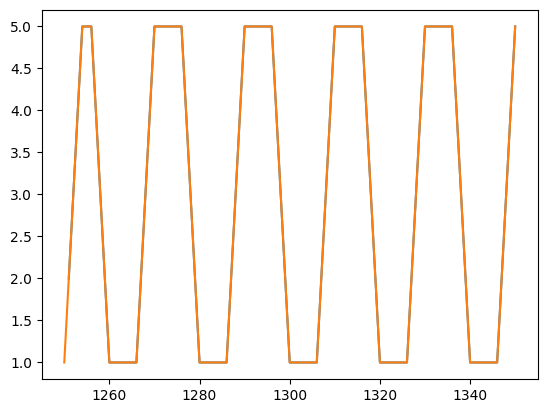

1500 training done (epochs=733)
240.517988838869
240.517988838869
Pregret: 0.0


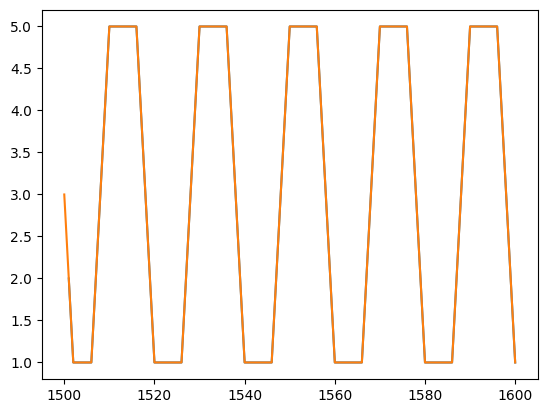

2048 training done (epochs=817)
236.02947834139022
236.02947834139022
Pregret: 0.0


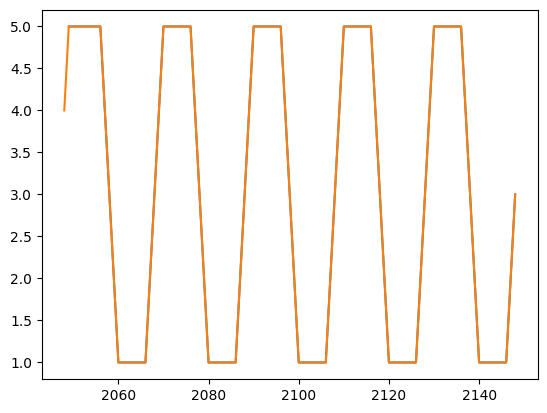

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


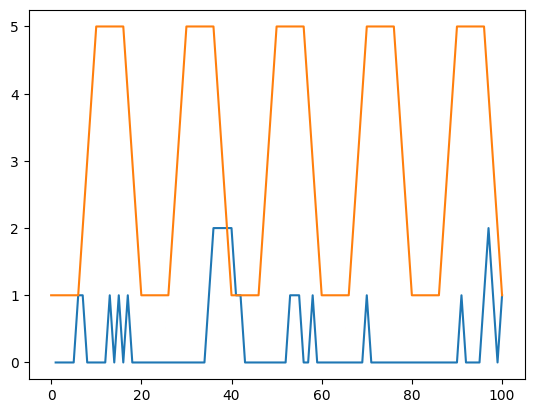

128 training done (epochs=200)
236.02947834139022
141.63291254520482
Pregret: 0.9439656579618539


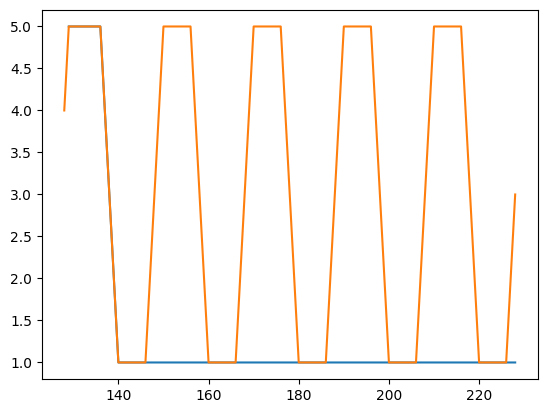

256 training done (epochs=316)
242.07326268668774
122.4597891940514
Pregret: 1.1961347349263634


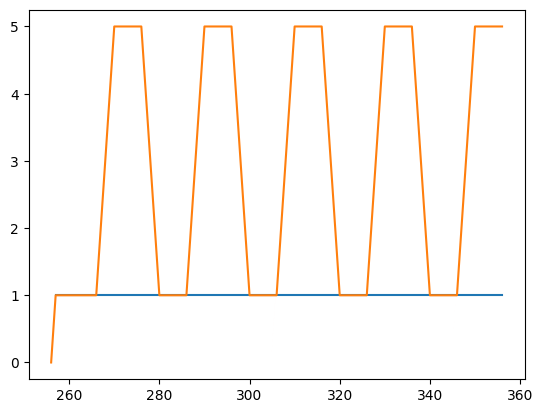

512 training done (epochs=464)
243.0074545823021
120.26582436117191
Pregret: 1.227416302211302


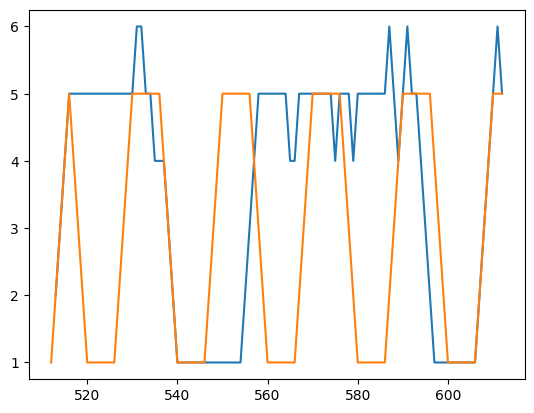

750 training done (epochs=555)
240.517988838869
109.42231516705677
Pregret: 1.3109567367181223


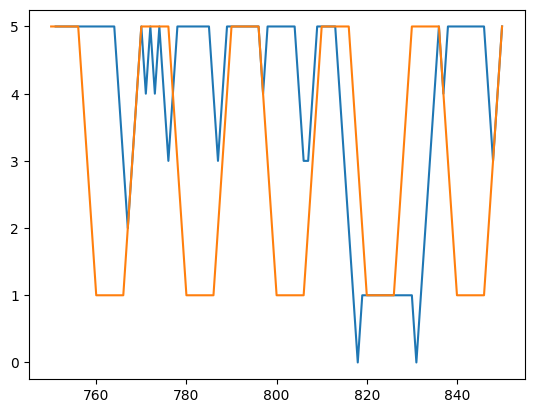

1024 training done (epochs=633)
243.60850098328575
199.11259075305523
Pregret: 0.44495910230230523


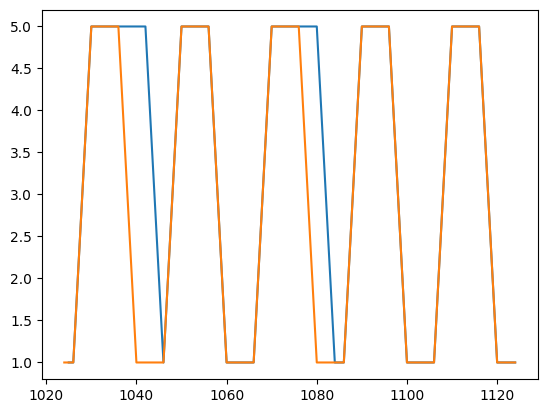

1250 training done (epochs=685)
240.517988838869
240.517988838869
Pregret: 0.0


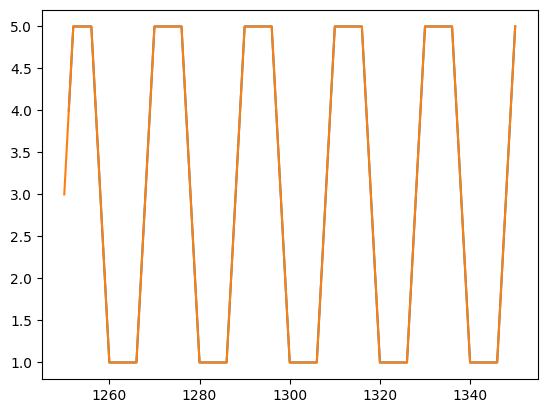

1500 training done (epochs=733)
240.517988838869
240.517988838869
Pregret: 0.0


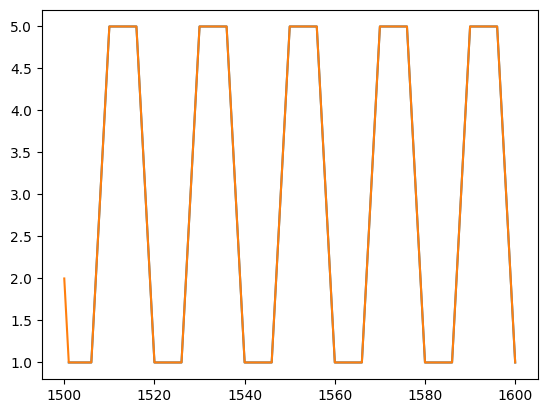

2048 training done (epochs=817)
236.02947834139022
236.02947834139022
Pregret: 0.0


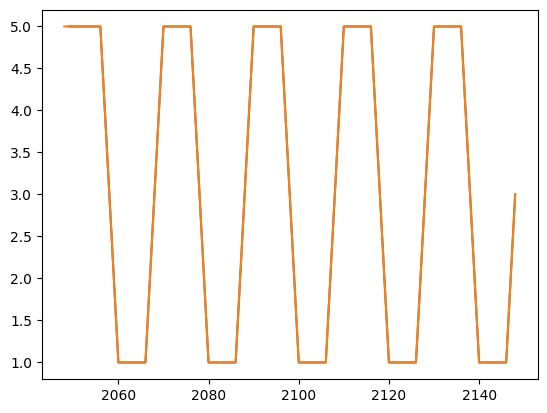

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


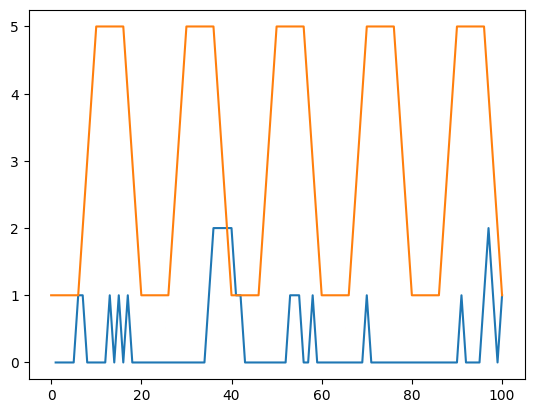

128 training done (epochs=200)
231.02947834139022
99.66397369929679
Pregret: 1.3136550464209342


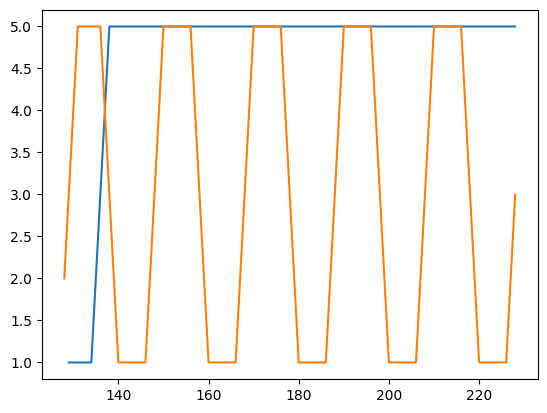

256 training done (epochs=316)
242.07326268668774
124.71139312982405
Pregret: 1.173618695568637


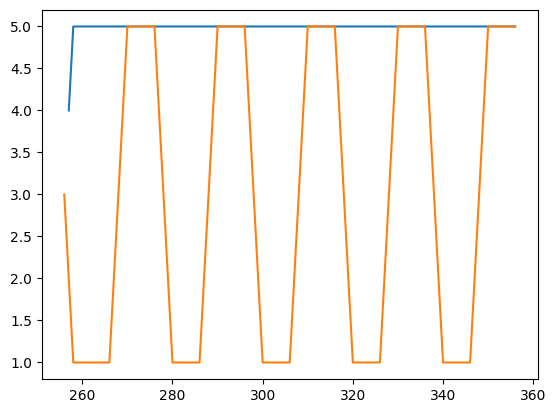

512 training done (epochs=464)
244.2386545823021
125.55796214064048
Pregret: 1.1868069244166162


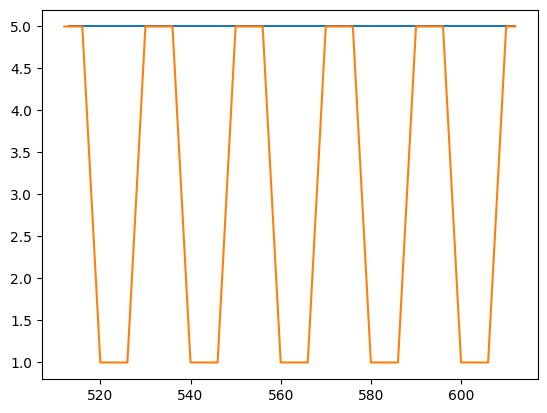

750 training done (epochs=555)
238.71798883886902
144.90129784120694
Pregret: 0.9381669099766208


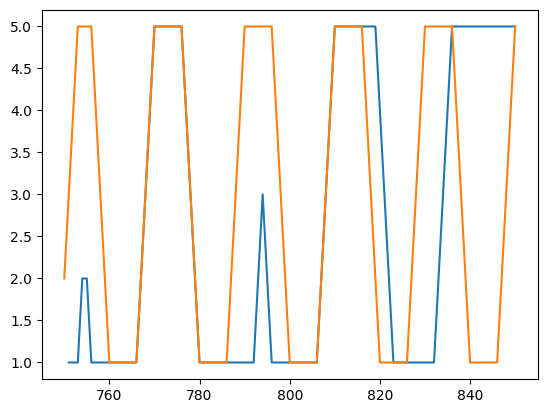

1024 training done (epochs=633)
243.37522098328574
183.32642059659324
Pregret: 0.600488003866925


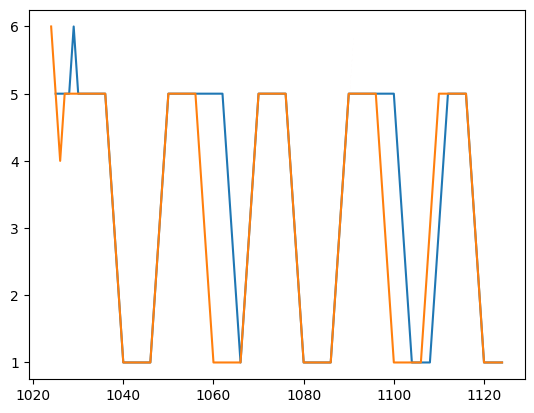

1250 training done (epochs=685)
240.517988838869
240.517988838869
Pregret: 0.0


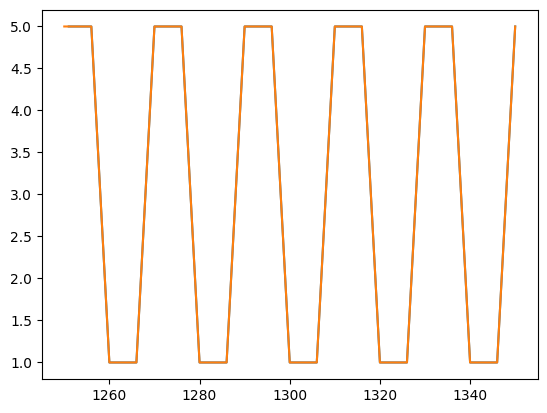

1500 training done (epochs=733)
235.963988838869
235.963988838869
Pregret: 0.0


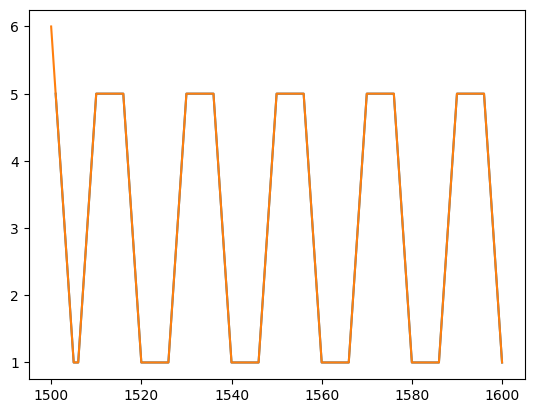

2048 training done (epochs=817)
223.37947834139024
223.37947834139024
Pregret: 0.0


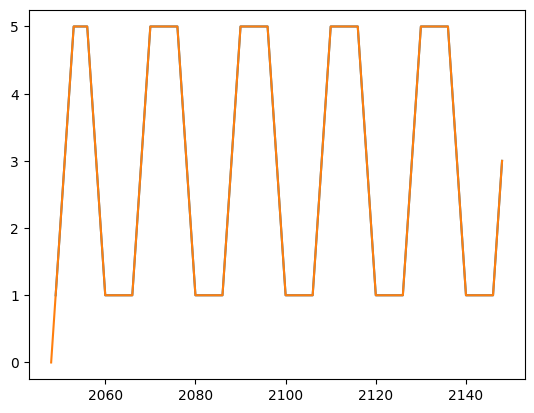

0 training done (epochs=0)
240.517988838869
26.394493524145823
Pregret: 2.1412349531472317


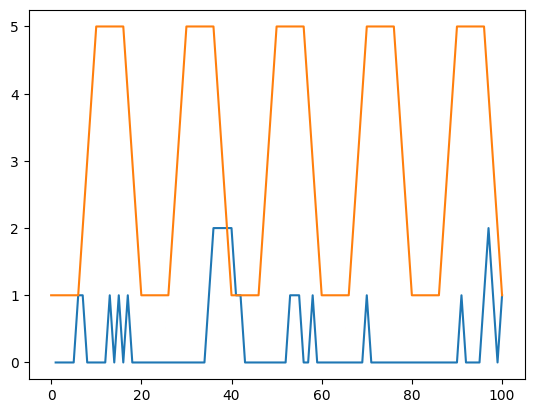

128 training done (epochs=200)
236.02947834139022
124.47404754520481
Pregret: 1.115554307961854


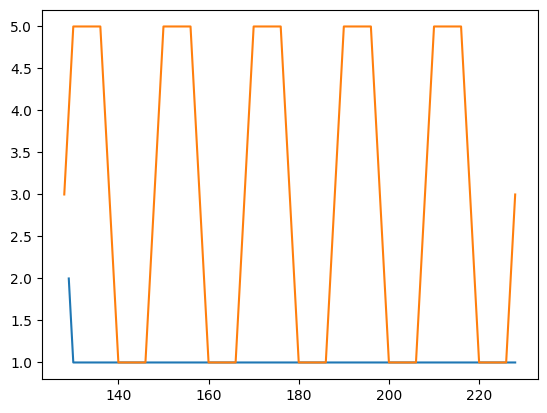

256 training done (epochs=316)
242.07326268668774
122.4597891940514
Pregret: 1.1961347349263634


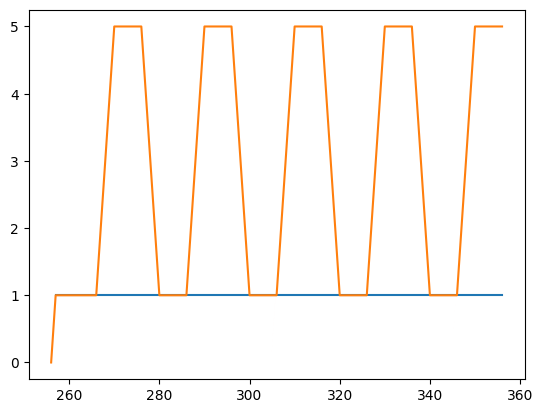

512 training done (epochs=464)
244.2386545823021
125.779935652999
Pregret: 1.184587189293031


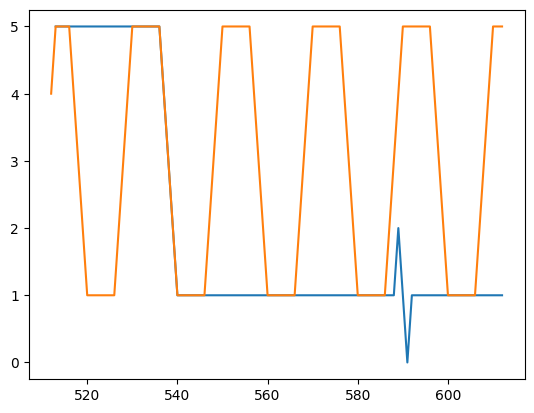

750 training done (epochs=555)
240.517988838869
185.6623178014082
Pregret: 0.5485567103746081


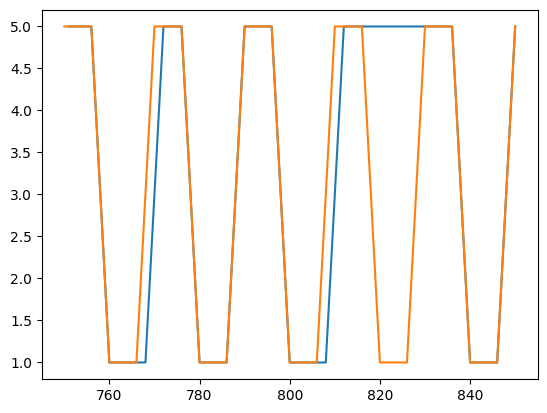

1024 training done (epochs=633)
243.60850098328575
219.85735641552938
Pregret: 0.2375114456775637


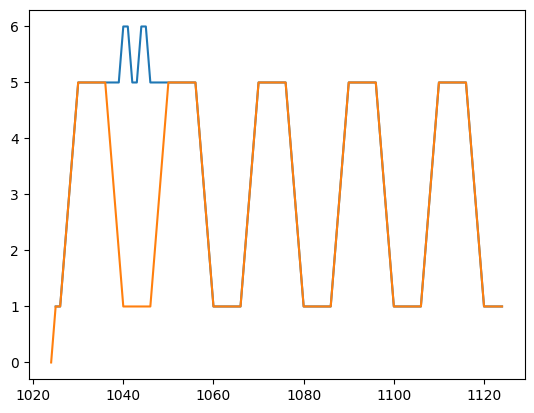

1250 training done (epochs=685)
240.517988838869
240.517988838869
Pregret: 0.0


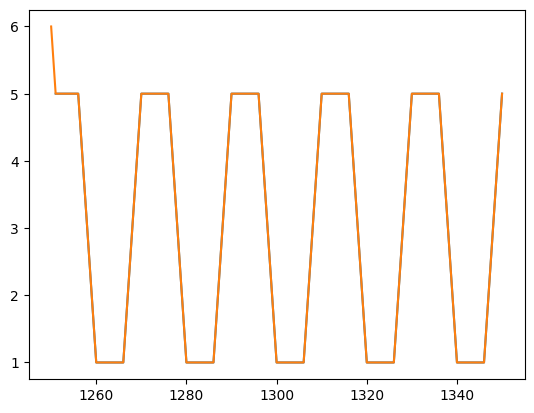

1500 training done (epochs=733)
240.517988838869
240.517988838869
Pregret: 0.0


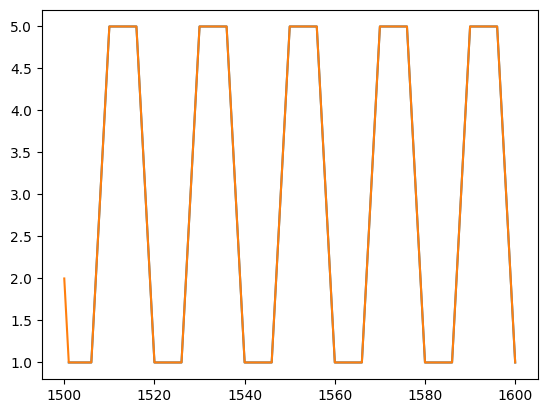

2048 training done (epochs=817)
231.02947834139022
231.02947834139022
Pregret: 0.0


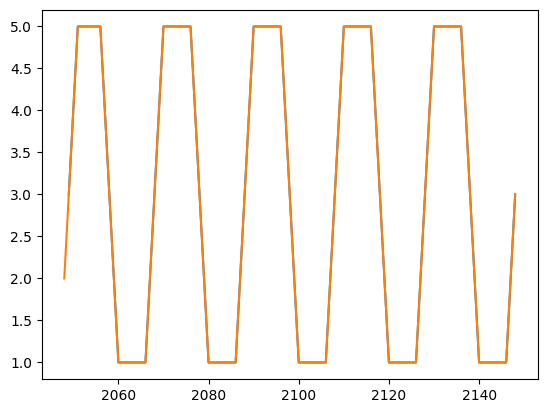

In [9]:
gamma = 0.5
Ts = [0,128,256,512,750,1024,1250,1500,2048]

T0 = 128          # Min Time
base_epoch = 200  # Min Epoch

for rep in range(10):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(
            rewards_in_period = rewards_in_period,
            session_duration = 500000,
            tdim=50,
            n_sessions=1,
            seed  = 515 + rep
        )

        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

        trainer = TorchMLPTrainer(in_dim=new_state_oh.shape[1])

        for T in Ts:
            if T == 0:
                n_samples = 50
                X_train = new_state_oh[:n_samples,:]
                Y_train = np.random.permutation(irewards[:n_samples])
                epochs = int(base_epoch * math.log2(T / T0 + 1))
                trainer.partial_fit(X_train, Y_train, epochs=epochs)
            else: 
                X_train = new_state_oh[:T,:]
                Y_train = irewards[:T]

            # Dynamic number of epochs
                epochs = int(base_epoch * math.log2(T / T0 + 1))
                trainer.partial_fit(X_train, Y_train, epochs=epochs)
            print(f"{T} training done (epochs={epochs})")

            current_state = states[T,0]
            future_states = [current_state]

            for delta_t in range(100):
                df_all_paths = enumerate_paths(
                    x0=current_state,
                    t_inital = T+delta_t,
                    t_prime=t_prime
                )
                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(
                        np.ones(cand_pe.shape[0])*curr_time,
                        tdim=50
                    )
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = trainer.predict(features)

                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                rewards_matrix = df_ireward.iloc[:, 1:].values
                discounts = gamma ** np.arange(1, t_prime+1)

                discounted_returns = rewards_matrix * discounts
                total_discounted = discounted_returns.sum(axis=1)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                future_states.append(next_state)
                current_state = next_state

            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            print(np.sum(preward_opt_test))
            print(np.sum(preward))
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print("Pregret:", pregret)

            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PAFM/NN/Permute_NN_onehot_w_lookahead_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )